<a href="https://colab.research.google.com/github/alanapooler827/554Homework4/blob/main/Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

## Homework 4

### Read in student data

In [ ]:
df = pd.read_table('https://www4.stat.ncsu.edu/online/datasets/StudentData.txt', sep = ';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### Summarize the data

#### Categorical Variables

Create a one-way contingency table, a two-way contingency table, and a three-way contingency table

Interpret a number from each resulting table (that is, pick out a value produced and explain whatthat value means.)

There are 208 female subjects in the data set.

In [ ]:
# one-way contingency table
df.sex.value_counts()

There are 23 female subjects whose parents live apart

In [ ]:
# two way contingency table
pd.crosstab(df.sex, df.Pstatus)

There are 19 females who live in an urban area and have parents that live apart in the data set.

In [ ]:
pd.crosstab([df.sex, df.Pstatus], df.address)

Conditional 2-way table

There are 17 students who live in urban areas, have a family of more than 3 people, and have parents that live apart.

In [ ]:
# subsetting data first
df_subset = df.loc[df['address'] == 'U']

pd.crosstab(df_subset.famsize, df_subset.Pstatus)

There are 128 male students who live in urban areas and have parents that live together

In [ ]:
# creating 3-way table and subsetting it
tab = pd.crosstab([df.sex, df.Pstatus], df.address)
tab.loc[:, "U"]

#### Numeric Variables

The numeric variables are age, absences, and the three test grades variables (G1, G2, and G3)

Find measures of center and spread for three of these variables (including G3 as one of them)

In [ ]:
print(round(df[['G3', 'age', 'absences']].mean(), 4))

print(round(df[['G3', 'age', 'absences']].median(), 4))

print(round(df[['G3', 'age', 'absences']].std(), 4))

Repeat while subsetting the data by some grouping variable (say with .loc)

In [ ]:
df_subset = df[df['sex'] == 'F']

print(round(df_subset[['G3', 'age', 'absences']].mean(), 4))

print(round(df_subset[['G3', 'age', 'absences']].median(), 4))

print(round(df_subset[['G3', 'age', 'absences']].std(), 4))

Find measures of center and spread across a single grouping variable for three of these variables (including G3 as one of them)

In [ ]:
print(round(df.groupby('sex')[['G3', 'age', 'absences']].mean(), 4))

print(round(df.groupby('sex')[['G3', 'age', 'absences']].median(), 4))

print(round(df.groupby('sex')[['G3', 'age', 'absences']].std(), 4))

Create a correlation matrix between all of the numeric variables

In [ ]:
df[['age', 'absences', 'G1', 'G2', 'G3']].corr()

### Visualizations

#### Categorical Variables

Create a stacked bar graph and a side-by-side bar graph. Give relevant x and y labels, and a title for the plots.

Overall, more students live in urban areas than rural areas. Most students have a 1-15 minute commute from home to school. As the travel time increases, the number of students in that group that live in urban areas decreases more than the number of students that live in rural areas.

<Axes: title={'center': 'Travel Time to School by Address Type'}, xlabel='Travel Time', ylabel='Number of Students'>

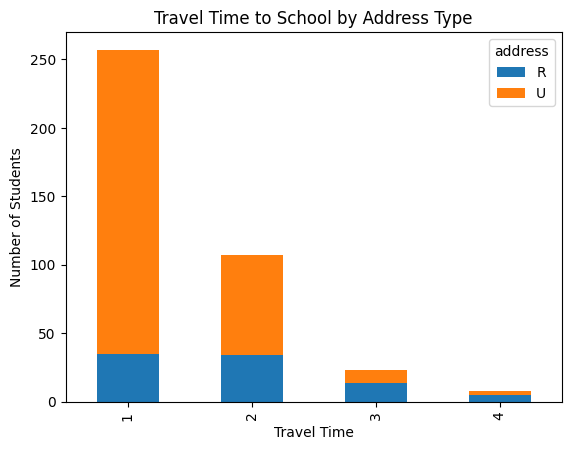

In [ ]:
# stacked bar graph
table = pd.crosstab(df.traveltime, df.address)
table.plot.bar(stacked = True, title = 'Travel Time to School by Address Type',
               xlabel = 'Travel Time',
               ylabel = 'Number of Students')

Most students have not failed any classes. A relationship between having extra paid support and failing less classes can be seen, as not as many students who have extra support fail classes vs students who do not have extra support.

<Axes: title={'center': 'Number of Class Failures by Extra Paid Support (Y/N)'}, xlabel='Number of Class Failures', ylabel='Number of Students'>

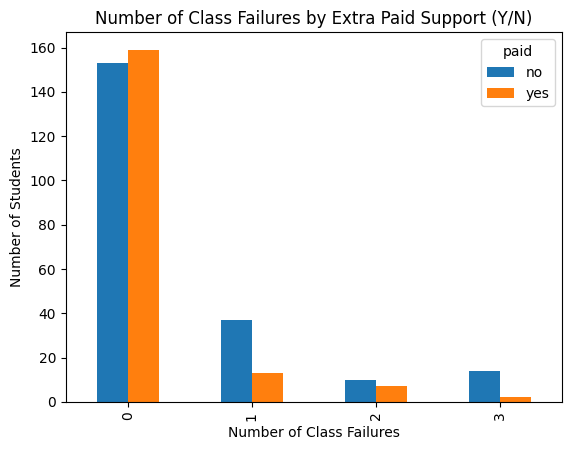

In [ ]:
# side-by-side bar graph
table = pd.crosstab(df.failures, df.paid)
table.plot.bar(title = 'Number of Class Failures by Extra Paid Support (Y/N)',
               xlabel = 'Number of Class Failures',
               ylabel = 'Number of Students')

#### Numeric Variables

The numeric variables are age, absences, and the three test grades variables (G1, G2, and G3)

Create a histogram, kernel density plot, and boxplot for two of the numeric variables across one of the categorical variables (that is, create graphs that can compare the distributions across the groups). For
at least one of the kernel density plots across groups, make sure that the graphs are overlayed on the same plot. Add appropriate labels and titles.

Histograms

From this graph, we can see that Gabriel Pereira has a lot more students than Mousinho da Silveira. GP has a lower minimum for the test scores than MS. GP also has a more defined bell shape than MS.

In [ ]:
bin_ends = 10
bins = [i*max(df.G1)/bin_ends for i in range(0, bin_ends + 1)]

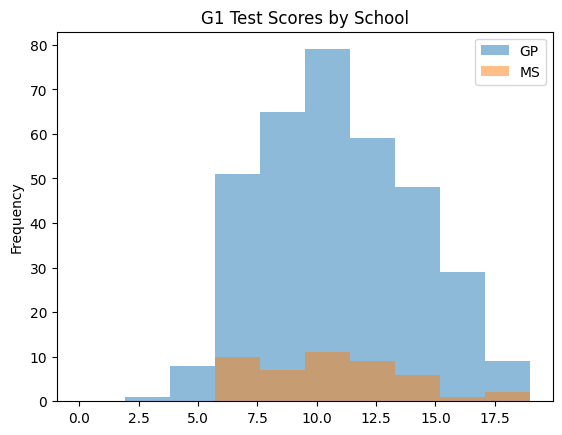

In [ ]:
gp_grade = df.loc[df.school == "GP", "G1"]
ms_grade = df.loc[df.school == "MS", "G1"]

gp_grade.plot.hist(bins = bins, alpha = 0.5, label = "GP",
                   title = "G1 Test Scores by School") \
                   .set(xlabel = "G1 Test Score")
ms_grade.plot.hist(bins = bins, alpha = 0.5, label = "MS")
plt.legend()

GP has a much wider range of absences than MS, with the maximum for GP being around 70, while the maximum for MS is around 15. At both schools, most students have about 0-5 absences.

/tmp/ipython-input-1908631851.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.hist(column = "absences", by = "school")


array([<Axes: title={'center': 'GP'}>, <Axes: title={'center': 'MS'}>],
      dtype=object)

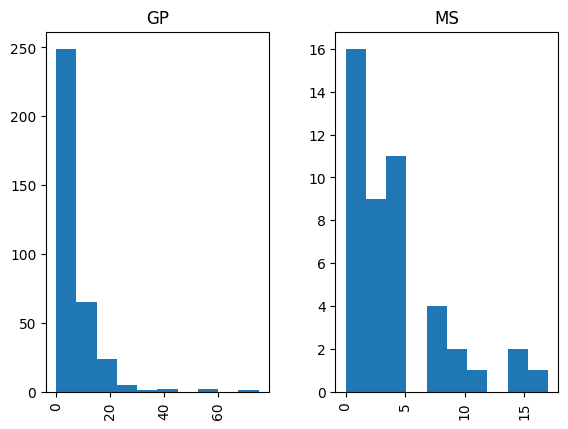

In [ ]:
df.hist(column = "absences", by = "school")

Kernel Density Plot

The test scores at MS are more variable than the test scores at GP. The line for MS has 3 distinct peaks, while the line for GP has only one.

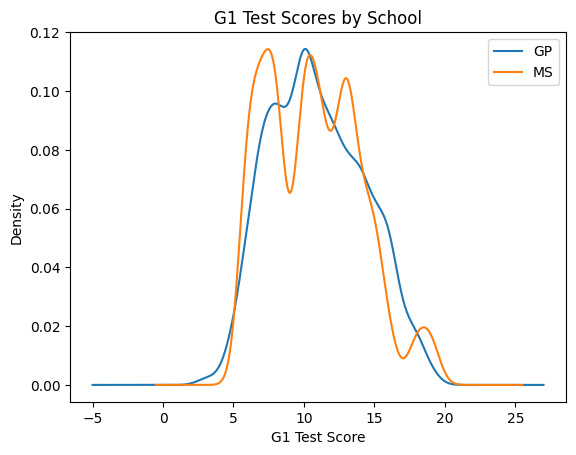

In [ ]:
gp_grade.plot.density(bw_method = 0.2, label = 'GP',
                         title = "G1 Test Scores by School") \
                         .set(xlabel = "G1 Test Score")
ms_grade.plot.density(bw_method = 0.2, label = 'MS',
                         title = "G1 Test Scores by School") \
                         .set(xlabel = "G1 Test Score")
plt.legend()

MS has a much higher density at zero absences than GP. The density line for GP also peaks at zero, but has a slower decline until around 20 absences, whereas the line for MS declines quickly and ends around 20 absences.

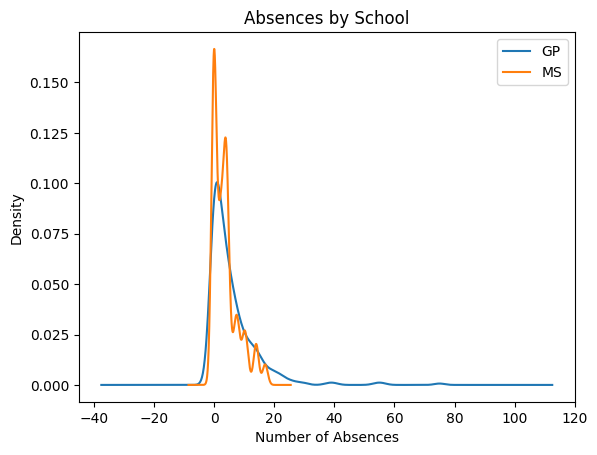

In [ ]:
gp_absences = df.loc[df.school == "GP", "absences"]
ms_absences = df.loc[df.school == "MS", "absences"]

gp_absences.plot.density(bw_method = 0.2, label = 'GP',
                         title = "Absences by School") \
                         .set(xlabel = "Number of Absences")
ms_absences.plot.density(bw_method = 0.2, label = 'MS')
plt.legend()

Boxplots

The box sizes/IQR for each school are pretty similar, although GP has a higher median than MS. The lower tail for GP is much longer than it is for MS.

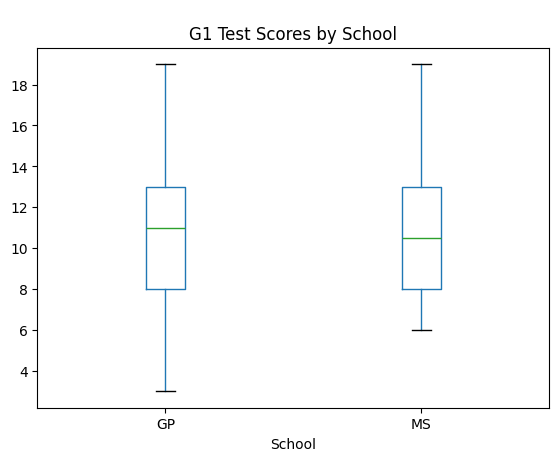

In [ ]:
df.boxplot(column = ["G1"], by = "school")

plt.xlabel("School")
plt.title("G1 Test Scores by School")
plt.suptitle(" ")
plt.grid(False)

GP has a much longer tail and a lot more outliers for number of absences than MS does. The box for MS is very small with a short upper tail, and both boxes have no lower tail.

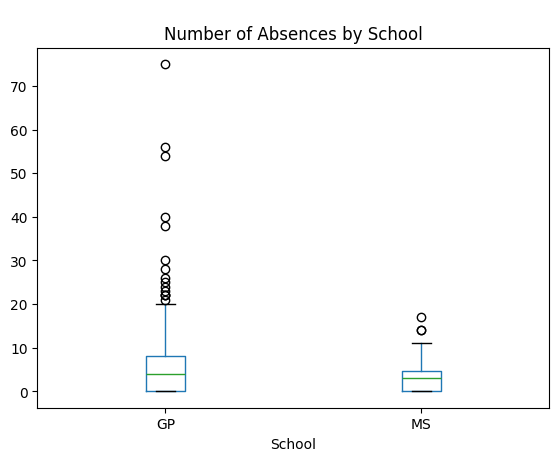

In [ ]:
df.boxplot(column = ["absences"], by = "school")

plt.xlabel("School")
plt.title("Number of Absences by School")
plt.suptitle(" ")
plt.grid(False)

Create two scatterplots relating G3 to other numeric variables (G3 on the y-axis). Color the points by a categorical variable in each. Add appropriate labels and titles.

The range of G3 test scores is similar between both schools, but the number of absences goes much higher at GP. We can see a slight relationship between number of absences and test scores, with students with more absences generally scoring lower on tests.

<Axes: title={'center': 'Number of Absences vs G1 Test Score, Colored by School'}, xlabel='absences', ylabel='G3'>

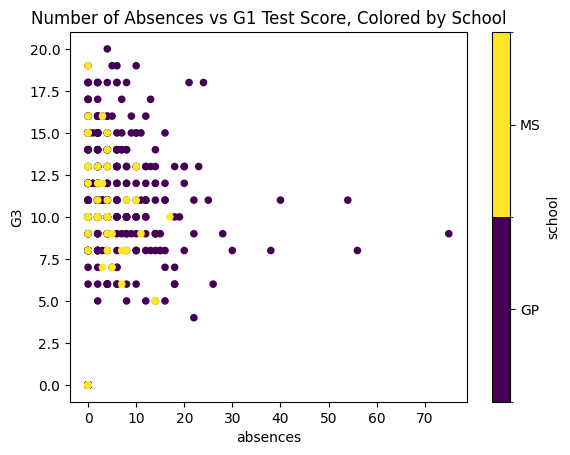

In [ ]:
df['school'] = df['school'].astype('category')
df.plot.scatter(x = "absences", y = "G3", c = "school", colormap = "viridis", title = 'Number of Absences vs G3 Test Score, Colored by School')

There is a clear relationship between G1 and G3 scores- students who did well on one test generally also did well on the other test. I don't see any obvious relationship between gender and test scores.

<Axes: title={'center': 'Age vs G3 Test Score, Colored by Sex'}, xlabel='G1', ylabel='G3'>

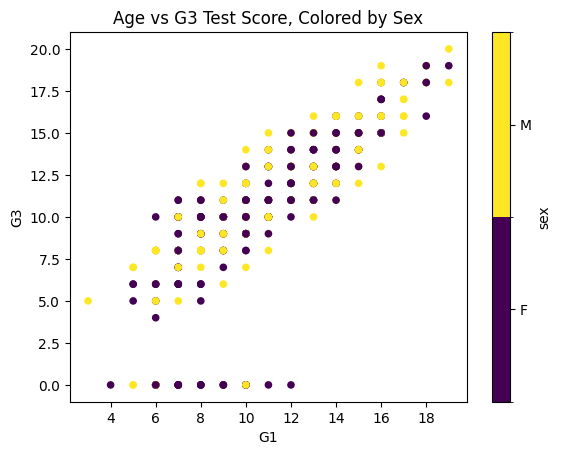

In [ ]:
df['sex'] = df['sex'].astype('category')
df.plot.scatter(x = "G1", y = "G3", c = "sex", colormap = "viridis", title = 'Age vs G3 Test Score, Colored by Sex')

## Plotting NFL Data

Read in data

In [3]:
scores = pd.read_csv("https://www4.stat.ncsu.edu/~online/datasets/scoresFull.csv")
scores.head()

,week,date,day,season,awayTeam,AQ1,AQ2,AQ3,AQ4,AOT,...,homeFumLost,homeNumPen,homePenYds,home3rdConv,home3rdAtt,home4thConv,home4thAtt,homeTOP,HminusAScore,homeSpread
0,1,5-Sep,Thu,2002,San Francisco 49ers,3,0,7,6,-1,...,0,10,80,4,8,0,1,32.47,-3,-4.0
1,1,8-Sep,Sun,2002,Minnesota Vikings,3,17,0,3,-1,...,1,4,33,2,6,0,0,28.48,4,4.5
2,1,8-Sep,Sun,2002,New Orleans Saints,6,7,7,0,6,...,0,8,85,1,6,0,1,31.48,-6,6.0
3,1,8-Sep,Sun,2002,New York Jets,0,17,3,11,6,...,1,10,82,4,8,2,2,39.13,-6,-3.0
4,1,8-Sep,Sun,2002,Arizona Cardinals,10,3,3,7,-1,...,0,7,56,6,10,1,2,34.40,8,6.0


In [57]:
scores[scores['week']=='14'][['homeTeam', 'awayTeam', 'AFinal', 'HFinal']]

,homeTeam,awayTeam,AFinal,HFinal
192,New England Patriots,Buffalo Bills,17,27
193,Jacksonville Jaguars,Cleveland Browns,21,20
194,San Diego Chargers,Oakland Raiders,27,7
195,Baltimore Ravens,New Orleans Saints,37,25
196,Carolina Panthers,Cincinnati Bengals,31,52
...,...,...,...,...
3407,Cincinnati Bengals,Pittsburgh Steelers,42,21
3408,Tennessee Titans,New York Giants,36,7
3409,Philadelphia Eagles,Seattle Seahawks,24,14
3410,Arizona Cardinals,Kansas City Chiefs,14,17


Convert the homeTeam, awayTeam, day, stadium, startTime, toss, roof, and surface to category type variables.

In [4]:
scores[[
    "homeTeam", "awayTeam", "day", "stadium", "startTime", "toss", "roof",
    "surface"
]] = scores[[
    "homeTeam", "awayTeam", "day", "stadium", "startTime", "toss", "roof",
    "surface"
]].astype("category")


### Summarize the data

In [5]:
# remove anything outside of weeks 1-17

scores = scores.loc[(scores["week"] >= '1') & (scores["week"] <= '17')]

Summarize some of the variables grouped by season and week, season alone, and week alone.

Produce some common numeric summaries of variables across these different groups. Similarly, produce some common plots over time.

Average home and away scores by season and week

In [16]:
scores.groupby(['season', 'week'])[['AFinal', 'HFinal']].mean()

AFinal     HFinal
season week                    
2002   1     23.1250  26.125000
       10    23.5000  22.571429
       11    18.3750  22.562500
       12    21.1875  21.000000
       13    19.0625  25.000000
...              ...        ...
2014   13    20.6875  27.312500
       14    27.0625  19.750000
       15    18.0000  18.437500
       16    22.8750  22.937500
       17    20.8125  20.500000

[117 rows x 2 columns]

Average halftime and final scores for home and away games grouped by season

In [21]:
scores.groupby('season')[['AQ2', 'AFinal', 'HQ2', 'HFinal']].mean()

,AQ2,AFinal,HQ2,HFinal
season,,,,
2002,5.584507,20.197183,7.302817,23.338028
2003,6.190141,18.028169,7.070423,23.570423
2004,6.302817,20.605634,6.943662,22.697183
2005,5.626761,18.816901,7.373239,22.084507
2006,6.458333,21.145833,5.819444,19.472222
2007,6.359155,20.056338,7.338028,23.415493
2008,6.408451,20.683099,7.366197,22.788732
2009,6.174825,19.727273,7.790210,22.300699
2010,6.640845,20.746479,7.091549,23.140845


Average halftime and final scores for home and away games grouped by week

In [20]:
scores.groupby('week')[['AQ2', 'AFinal', 'HQ2', 'HFinal']].mean()

,AQ2,AFinal,HQ2,HFinal
week,,,,
1,6.572115,19.716346,6.384615,22.139423
10,6.016129,21.543011,7.139785,22.983871
11,5.562189,19.592040,7.527363,22.582090
12,6.726829,21.507317,7.000000,22.878049
13,6.432692,20.437500,7.403846,23.201923
14,5.884615,19.394231,7.163462,24.605769
15,6.408654,20.942308,6.793269,22.543269
16,6.201923,20.802885,6.831731,22.168269
17,6.149038,19.235577,7.663462,23.807692


Average home game score by team

In [65]:
scores.groupby(['homeTeam'])['HFinal'].mean().sort_values(ascending = False)

/tmp/ipython-input-2833222626.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scores.groupby(['homeTeam'])['HFinal'].mean().sort_values(ascending = False)


,HFinal
homeTeam,
New England Patriots,28.719298
Green Bay Packers,28.316667
Denver Broncos,26.730769
Indianapolis Colts,26.087719
Philadelphia Eagles,25.754386
Seattle Seahawks,25.754386
Minnesota Vikings,25.490909
New Orleans Saints,25.436364
San Diego Chargers,25.169492


Plot of average home and away final scores by week

The average home game final scores are higher than the away game final scores, which I expected. In week 14, there is a large spike in home team scores, while away team scores dip. You can see the pattern start to repeat at week 17. Other than this, the lines somewhat reflect each other- when one increases, so does the other, and vice versa. More investigation would be needed to see why this pattern is happening.

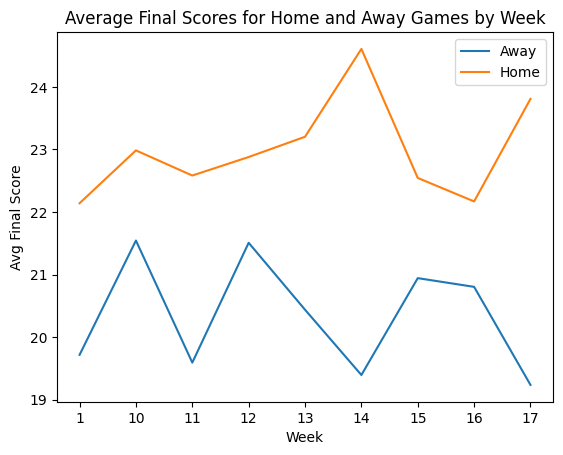

In [54]:
week_avg = scores.groupby('week')[['AFinal', 'HFinal']].mean().reset_index()

plt.plot(week_avg.week, week_avg.AFinal)
plt.plot(week_avg.week, week_avg.HFinal)
plt.xlabel('Week')
plt.ylabel('Avg Final Score')
plt.title('Average Final Scores for Home and Away Games by Week')
plt.legend(['Away', 'Home'])

Plot of Q2 and final scores for home and away games by week

Halftime scores are a bit lower than I expected compared to the final scores. At halftime, the away and home team scores are a bit closer than they are at the end of the game, but the home team still generally has a higher score at halftime than the away team.

<Axes: title={'center': 'Average Halftime and Final Scores for Home and Away Games by Week'}>

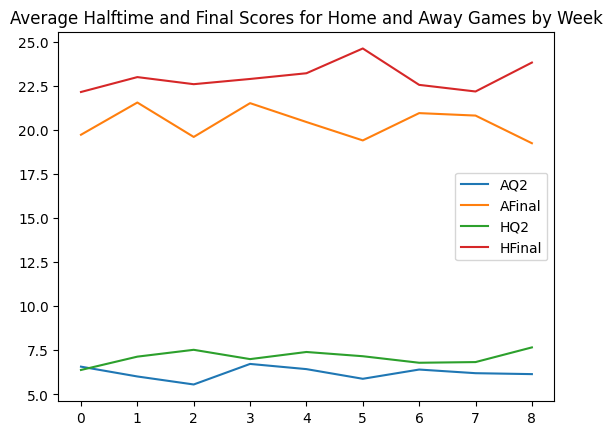

In [34]:
week_avg = scores.groupby('week')[['AQ2', 'AFinal', 'HQ2', 'HFinal']].mean().reset_index()
week_avg.plot.line(title = 'Average Halftime and Final Scores for Home and Away Games by Week')

Write at least one function that can be used to easily create a plot for this data.

In [38]:
# define decorator function to display run time
import time
from functools import wraps

def timeit(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        elapsed = end - start
        print(f"{func.__name__} ran in {elapsed:.6f} seconds")
        return result
    return wrapper

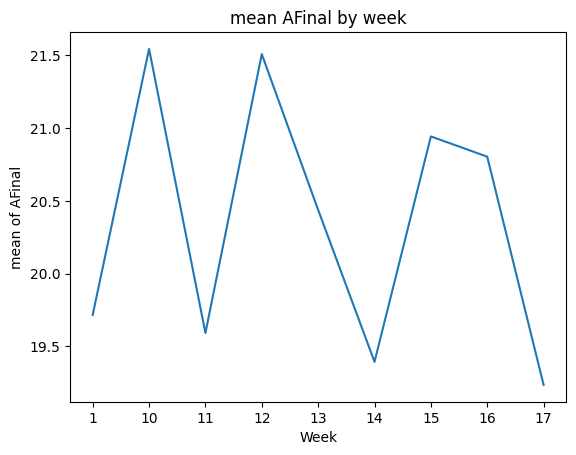

plot_group_stat ran in 0.177092 seconds


In [49]:
@timeit
def plot_group_stat(
    data: pd.DataFrame,
    group_col: str,
    value_col: str,
    stat: str = 'mean'
):
    """
    Plot a grouped statistic for a given variable over time.

    Args:
      data: Data frame to use
      group_col: column to group data by
      value_col: column to plot
      stat: statistic to calculate. Default is mean.
    """

    # calculate statistic for specified grouping column and value
    grouped = (data.groupby(group_col)[value_col]
                   .agg(stat)
                   .reset_index())

    plt.plot(grouped[group_col], grouped[value_col])
    plt.xlabel(group_col.title())
    plt.ylabel(f"{stat} of {value_col}")
    plt.title(f"{stat} {value_col} by {group_col}")
    plt.show()

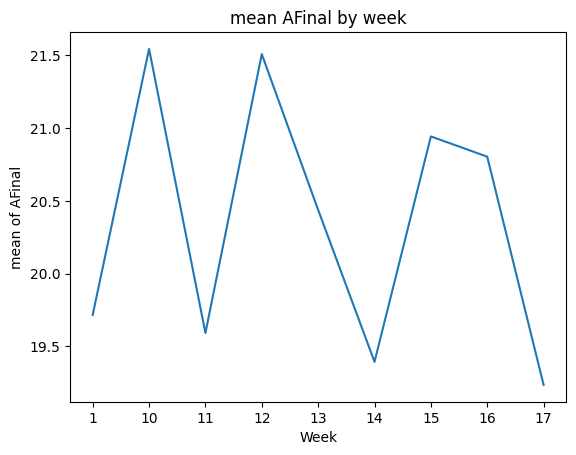

plot_group_stat ran in 0.303530 seconds


In [50]:
plot_group_stat(data = scores, group_col = 'week', value_col = 'AFinal', stat = 'mean')

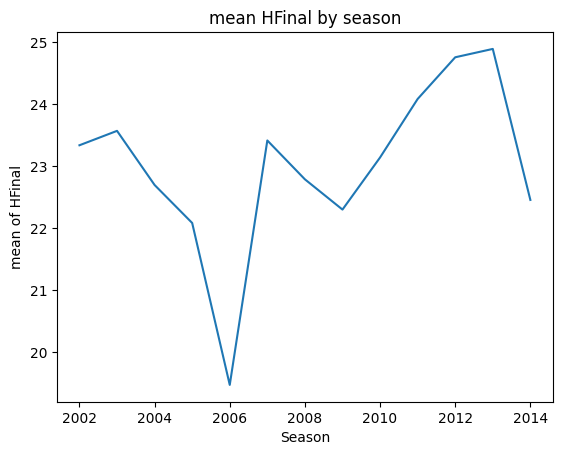

plot_group_stat ran in 0.131741 seconds


In [51]:
plot_group_stat(data = scores, group_col = 'season', value_col = 'HFinal', stat = 'mean')

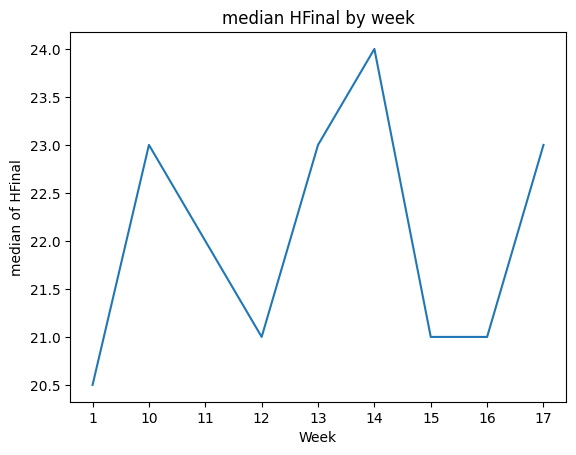

plot_group_stat ran in 0.144956 seconds


In [52]:
plot_group_stat(data = scores, group_col = 'week', value_col = 'HFinal', stat = 'median')